<h1 style="text-align:center;">Лабораторна робота 5</h1>

<p><b>Тема:</b> OpenCV. Просторові методи обробки зображень. Робота з околом. Просторова фільтрація зображення (short version) </p>
<p><b>Мета:</b> знайомство з просторовими методами фільтрації зображень засобами OpenCV у середовищі Anaconda із застосуванням Jupyter Notebook засобами мови програмування Python.</p>
<h2 style="font-weight:bold; font-size:22px;">Завдання для самостійної роботи</h2>

<p>1. <a href="https://docs.opencv.org/4.x/dc/dd3/tutorial_gausian_median_blur_bilateral_filter.html">Фільтр з ядром Гауса</a></p>

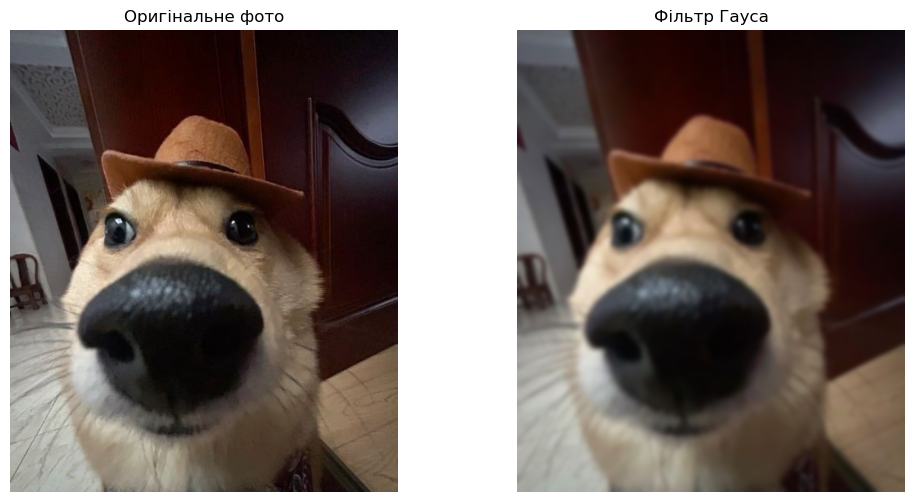

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

filename = 'scr/123.jpg' 
image = cv2.imread(filename)

if image is None:
    print(f"Помилка: Не вдалося знайти файл {filename}")
else:
    gaussian_blur = cv2.GaussianBlur(image, (15, 15), 0)
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    if len(image.shape) == 3:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(image, cmap='gray')
    plt.title("Оригінальне фото")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    if len(gaussian_blur.shape) == 3:
        plt.imshow(cv2.cvtColor(gaussian_blur, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(gaussian_blur, cmap='gray')
    plt.title("Фільтр Гауса")
    plt.axis('off')

    plt.show()

<p>Формула: Фільтрація Гауса використовує двовимірний гаусівський розподіл для розрахунку коефіцієнтів ядра згортки. Значення кожного пікселя обчислюється за формулою:</p>
$$
G(x, y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2 + y^2}{2\sigma^2}}
$$

<p>2. <a href="https://docs.opencv.org/4.x/dc/dd3/tutorial_gausian_median_blur_bilateral_filter.html">Двосторонній фільтр</a></p>

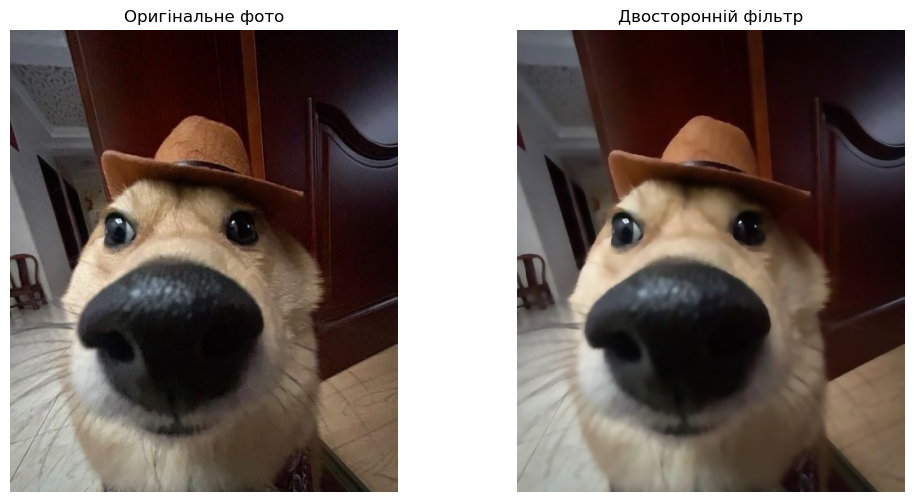

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

filename = 'scr/123.jpg' 
image = cv2.imread(filename)

if image is None:
    print(f"Помилка: Не вдалося знайти файл {filename}")
else:   
    bilateral_filter = cv2.bilateralFilter(image, d=9, sigmaColor=75, sigmaSpace=75)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    if len(image.shape) == 3:
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(image, cmap='gray')
    plt.title("Оригінальне фото")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    if len(bilateral_filter.shape) == 3:
        plt.imshow(cv2.cvtColor(bilateral_filter, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(bilateral_filter, cmap='gray')
    plt.title("Двосторонній фільтр")
    plt.axis('off')

    plt.show()

$$
g(x, y) = \frac{1}{W_p} \sum_{x_i, y_i \in \Omega} f(x_i, y_i) \cdot G_{\sigma_s}(\| (x,y) - (x_i,y_i) \|) \cdot G_{\sigma_r}(| f(x,y) - f(x_i,y_i) |)
$$

<p>Написати процедуру, яка б зашумлювала нормальним шумом з параметрами зображення</p>

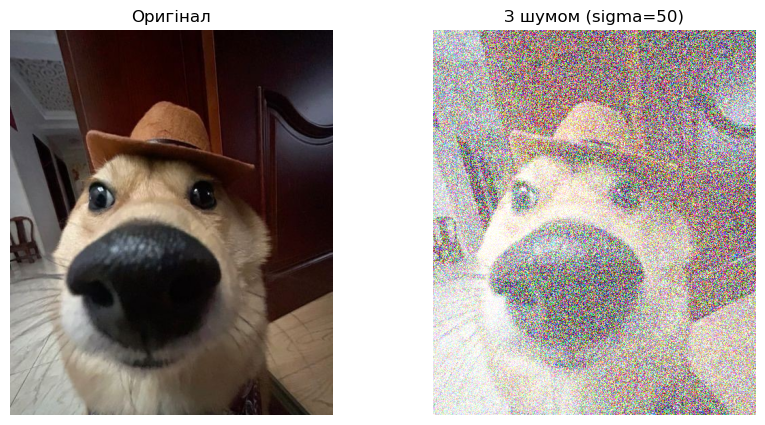

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def add_gaussian_noise(image, mean=0, sigma=25):
    noise = np.random.normal(mean, sigma, image.shape).astype('uint8')
    noisy_image = cv2.add(image, noise)
    
    return noisy_image

img = cv2.imread('scr/123.jpg') 

if img is not None:
    noisy_img = add_gaussian_noise(img, mean=0, sigma=50)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Оригінал")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(noisy_img, cv2.COLOR_BGR2RGB))
    plt.title(f"З шумом (sigma=50)")
    plt.axis('off')
    
    plt.show()
else:
    print("Зображення не знайдено. Перевірте шлях до файлу.")

<p>Реалізувати медіанний фільтр і продемонструвати послідовно роботу медіанного і гаусового фільтру, оптимально підібравши і обґрунтувавши значення параметрів</p>

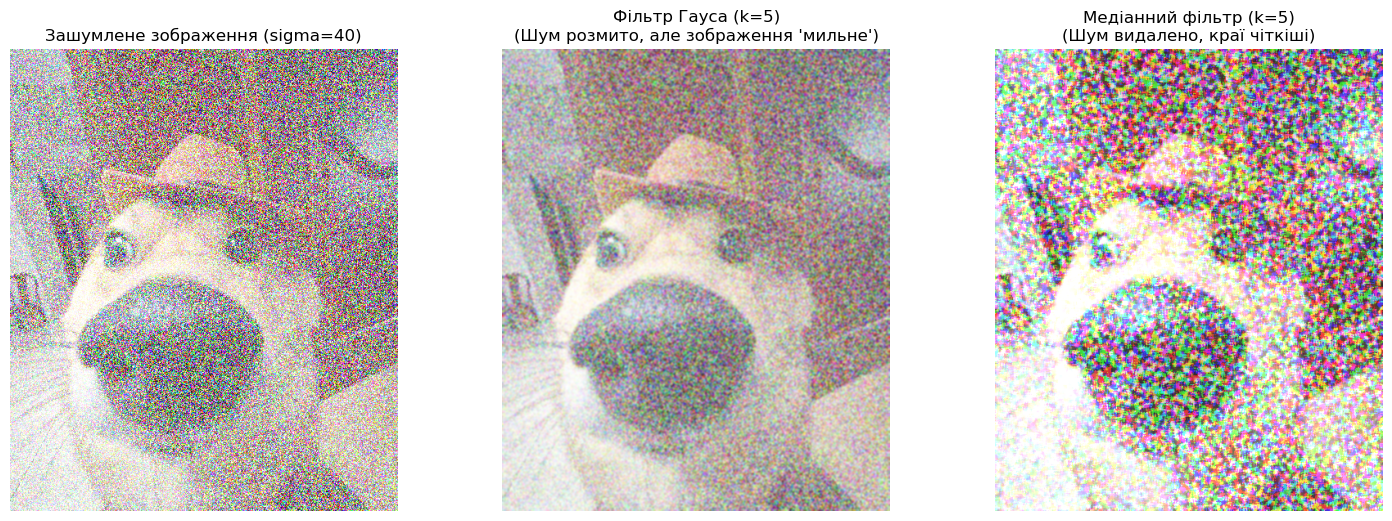

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def add_gaussian_noise(img, mean=0, sigma=40):
    noise = np.random.normal(mean, sigma, img.shape).astype('uint8')
    noisy_img = cv2.add(img, noise)
    return noisy_img

filename = 'scr/123.jpg'
image = cv2.imread(filename)

if image is None:
    print(f"Помилка: Файл '{filename}' не знайдено.")
else:
    noisy_image = add_gaussian_noise(image, sigma=40)

    k_size = 5

    gaussian_result = cv2.GaussianBlur(noisy_image, (k_size, k_size), 0)

    median_result = cv2.medianBlur(noisy_image, k_size)

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(noisy_image, cv2.COLOR_BGR2RGB))
    plt.title(f"Зашумлене зображення (sigma=40)")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(gaussian_result, cv2.COLOR_BGR2RGB))
    plt.title(f"Фільтр Гауса (k={k_size})\n(Шум розмито, але зображення 'мильне')")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(median_result, cv2.COLOR_BGR2RGB))
    plt.title(f"Медіанний фільтр (k={k_size})\n(Шум видалено, краї чіткіші)")
    plt.axis('off')

    plt.show()

<p>Для демонстрації було обрано параметр ядра $k=5$.</p>

<p>Чому не $k=3$?
При сильному шумі (наприклад, $\sigma=40$) вікно $3\times3$ є замалим. Воно не захоплює достатньо "чистих" пікселів, щоб статистично перекрити шум, тому зернистість залишається.</p>

<p>Чому не $k=7$ і більше?
Завелике ядро призводить до агресивного розмиття. Гаус перетворить об'єкт на пляму, а медіанний фільтр зробить зображення схожим на "пластиковий" малюнок, знищивши текстуру об'єкту.</p>

<p>Чому Медіана краща за Гауса?</p>

<p>Гаус — це усереднення. Він бере яскраву точку шуму і "розмазує" її по сусідніх пікселях. Шум стає менш яскравим, але перетворюється на плями.</p>

<p>Медіана — це вибір. Вона сортує пікселі у вікні та обирає середній. Оскільки шум — це екстремальне значення (дуже біле або дуже чорне), він опиняється в кінці списку сортування і просто ігнорується. Тому краї об'єктів залишаються чіткими.</p>

<p>Написати процедуру, до складу якої б входили всі низькочастотні фільтри, які досліджуються в цій лабораторній роботі, а вибір потрібного задавався відповідним вхідним параметром.</p>

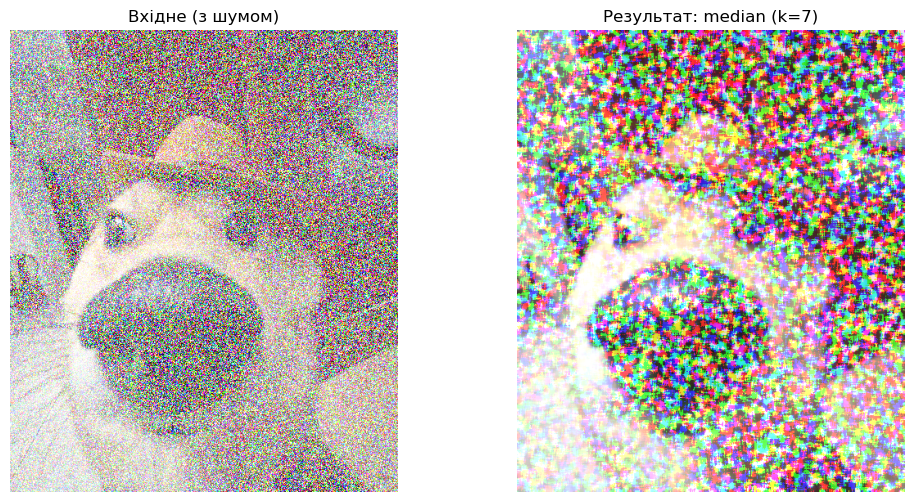

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def universal_filter(img, method, ksize=5):
    if method == 'box':
        return cv2.blur(img, (ksize, ksize))

    elif method == 'gaussian':
        return cv2.GaussianBlur(img, (ksize, ksize), 0)

    elif method == 'median':
        return cv2.medianBlur(img, ksize)

    elif method == 'bilateral':

        return cv2.bilateralFilter(img, d=ksize, sigmaColor=75, sigmaSpace=75)

    else:
        print(f"Увага: Метод '{method}' не знайдено. Повернення оригіналу.")
        return img

filename = 'scr/123.jpg'
image = cv2.imread(filename)

if image is None:
    print("Фото не знайдено.")
else:
    noisy_img = cv2.add(image, np.random.normal(0, 25, image.shape).astype('uint8'))

    filter_name = 'median'
    kernel_size = 7
    
    result = universal_filter(noisy_img, filter_name, kernel_size)

    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    if len(noisy_img.shape) == 3:
        plt.imshow(cv2.cvtColor(noisy_img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(noisy_img, cmap='gray')
    plt.title("Вхідне (з шумом)")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    if len(result.shape) == 3:
        plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(result, cmap='gray')
    plt.title(f"Результат: {filter_name} (k={kernel_size})")
    plt.axis('off')

    plt.show()

<h2 style="font-weight:bold; font-size:22px;">Контрольні запитання</h2>

<h>1. У чому полягає сенс градаційних перетворень?</h>

<p>Сенс градаційних перетворень полягає у зміні значень інтенсивності (яскравості) пікселів зображення за допомогою певної функції перетворення.</p>

<p>Це точкові операції (робота з околом $1 \times 1$), що означає, що нове значення пікселя $s$ залежить виключно від його початкового значення $r$ згідно з формулою $s = T(r)$.</p>

<p>Приклади таких перетворень включають:</p>

<ol>
    <li>Негатив.</li>
    <li>Логарифмічні та степеневі (гамма) перетворення.</li>
    <li>Соляризацію.</li>
</ol>

<h>2. На чому ґрунтуються гістограмні методи?</h>

<p>Гістограмні методи ґрунтуються на аналізі гістограми зображення — графіка, що відображає статистичний розподіл кількості пікселів для кожного рівня яскравості.</p>

<p>Ці методи використовують глобальну інформацію про зображення для:</p>

<ol>
    <li>Покращення контрасту: Наприклад, еквалізація гістограми "розтягує" діапазон яскравостей.</li>
    <li>Сегментації: Оцінка гістограми дозволяє знайти оптимальний поріг для бінаризації (розділення об'єкта і фону).</li>
</ol>